In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
# Load the dataset

df = pd.read_csv("car data.csv")

# Display first 5 rows
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [5]:
# Check dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [6]:
# Check rows and columns

df.shape

(301, 9)

In [7]:
# Display column names

df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='object')

In [8]:
# Check missing values

df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

In [9]:
# Statistical summary

df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [10]:
# Check unique values in categorical columns

print("Fuel Types:", df['Fuel_Type'].unique())
print("Selling Types:", df['Selling_type'].unique())
print("Transmission Types:", df['Transmission'].unique())
print("Owner Values:", df['Owner'].unique())

Fuel Types: ['Petrol' 'Diesel' 'CNG']
Selling Types: ['Dealer' 'Individual']
Transmission Types: ['Manual' 'Automatic']
Owner Values: [0 1 3]


In [11]:
# Create car age column

current_year = 2025
df['Car_Age'] = current_year - df['Year']

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,11
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,12
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,8
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,14
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,11


In [12]:
# Drop unnecessary columns

df = df.drop(['Car_Name', 'Year'], axis=1)

df.head()

,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,11
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,12
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,8
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,14
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,11


In [13]:
# Encode categorical columns

df = pd.get_dummies(df, drop_first=True)

df.head()

,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,11,False,True,False,True
1,4.75,9.54,43000,0,12,True,False,False,True
2,7.25,9.85,6900,0,8,False,True,False,True
3,2.85,4.15,5200,0,14,False,True,False,True
4,4.60,6.87,42450,0,11,True,False,False,True


In [14]:
# Check final dataset columns after encoding

df.columns

Index(['Selling_Price', 'Present_Price', 'Driven_kms', 'Owner', 'Car_Age',
       'Fuel_Type_Diesel', 'Fuel_Type_Petrol', 'Selling_type_Individual',
       'Transmission_Manual'],
      dtype='object')

In [15]:
# Split data into features and target

X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

In [16]:
# Split dataset into training and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
# Train Linear Regression model

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:
# Prediction using Linear Regression

linear_pred = linear_model.predict(X_test)

In [19]:
# Evaluate Linear Regression model

print("Linear Regression Results")
print("MAE:", mean_absolute_error(y_test, linear_pred))
print("MSE:", mean_squared_error(y_test, linear_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, linear_pred)))
print("R2 Score:", r2_score(y_test, linear_pred))

Linear Regression Results
MAE: 1.216374019333035
MSE: 3.4813498305118156
RMSE: 1.8658375680942367
R2 Score: 0.8488707839193155


In [20]:
# Train Random Forest Regressor model

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [21]:
# Prediction using Random Forest

rf_pred = rf_model.predict(X_test)

In [22]:
# Evaluate Random Forest model

print("Random Forest Regressor Results")
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("MSE:", mean_squared_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2 Score:", r2_score(y_test, rf_pred))

Random Forest Regressor Results
MAE: 0.6368655737704919
MSE: 0.9339387986885236
RMSE: 0.9664050903676592
R2 Score: 0.9594566919773236


In [23]:
# Compare actual and predicted prices

comparison = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': rf_pred
})

comparison.head(10)

,Actual Price,Predicted Price
177,0.35,0.4438
289,10.11,10.9098
228,4.95,4.9315
198,0.15,0.2159
60,6.95,7.7988
9,7.45,6.2535
118,1.10,1.1065
154,0.50,0.5876
164,0.45,0.4690
33,6.00,6.8960


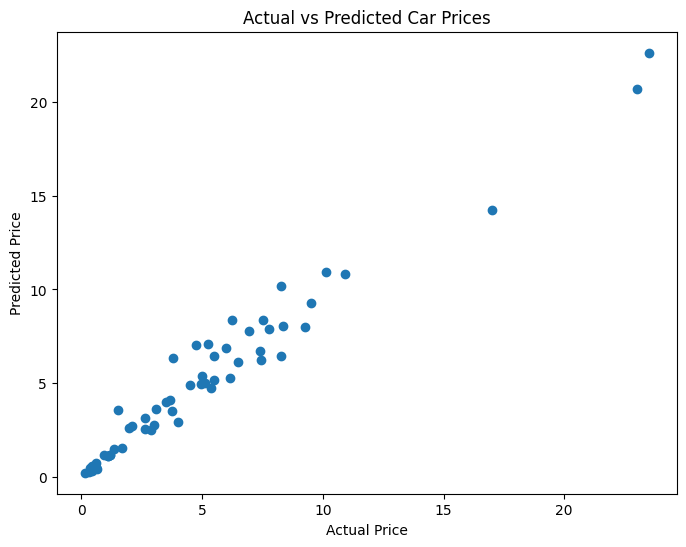

In [24]:
# Actual vs Predicted prices visualization

plt.figure(figsize=(8, 6))
plt.scatter(y_test, rf_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")
plt.show()

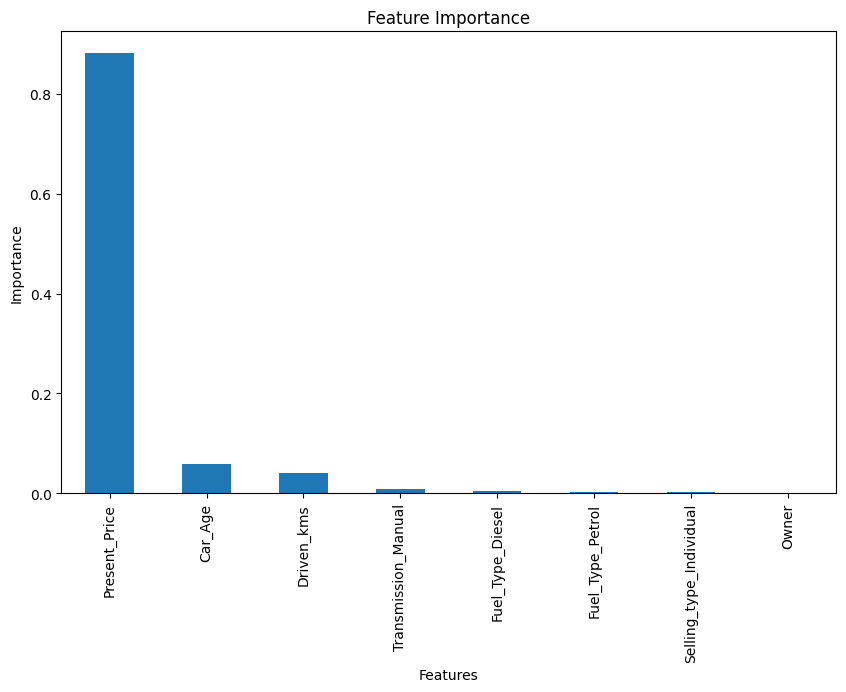

In [25]:
# Feature importance using Random Forest

importance = pd.Series(rf_model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importance.plot(kind='bar')
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

In [26]:
# Predict price for a custom car

sample_car = pd.DataFrame({
    'Present_Price': [5.59],
    'Driven_kms': [27000],
    'Owner': [0],
    'Car_Age': [11],
    'Fuel_Type_Diesel': [0],
    'Fuel_Type_Petrol': [1],
    'Selling_type_Individual': [0],
    'Transmission_Manual': [1]
})

predicted_price = rf_model.predict(sample_car)
print("Predicted Selling Price:", predicted_price[0])

Predicted Selling Price: 3.862500000000004
